# ADVI with Minibatch Iterators

This notebook demonstrates the `Trainer.fit` API for streaming minibatches through
stochastic variational inference.  The `Trainer` owns the training loop; the model
owns the math.  An iterator feeds one batch per step, and the trainer handles
compilation, gradient estimation, and optional likelihood rescaling so that the
minibatch ELBO is an unbiased estimate of the full-data one.

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm

from pymc_extras.inference.advi import Trainer, fit_advi

## 1.  Quick start: `fit_advi` on a small conjugate model

`fit_advi` is the one-liner convenience wrapper.  It builds a mean-field
AutoDiagonalNormal guide, compiles a clipped-Adam step function, runs the
training loop, and returns posterior
draws as a `DataTree`.

In [2]:
rng = np.random.default_rng(42)
true_theta = 1.5
obs = rng.normal(true_theta, 1.0, size=20)

with pm.Model() as conjugate_model:
    theta = pm.Normal("theta", 0, 5)
    pm.Normal("y", theta, 1, observed=obs)

idata = fit_advi(conjugate_model, n_steps=5_000, draws=2_000, random_seed=1)
idata

Output()

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:  (chain: 1, draw: 2000)
│       Coordinates:
│         * chain    (chain) int64 8B 0
│         * draw     (draw) int64 16kB 0 1 2 3 4 5 6 ... 1994 1995 1996 1997 1998 1999
│       Data variables:
│           theta    (chain, draw) float64 16kB 1.83 1.153 1.9 ... 1.902 1.659 1.282
│       Attributes:
│           created_at:                 2026-08-12T15:24:55.178064+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.1.0
│           sample_dims:                ['chain', 'draw']
├── Group: /observed_data
│       Dimensions:  (y_dim_0: 20)
│       Coordinates:
│         * y_dim_0  (y_dim_0) int64 160B 0 1 2 3 4 5 6 7 8 ... 12 13 14 15 16 17 18 19
│       Data variables:
│           y        (y_dim_0) float64 160B 1.805 0.46 2.25 2.441 ... 0.5411 2.378 1.45
│       Attributes:
│           created_at:                 2026-08-12T15:24:55.179230+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.1.0
│           sample_dims:                []
├── Group: /constant_data
│       Attributes:
│           created_at:                 2026-08-12T15:24:55.179569+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.1.0
│           sample_dims:                []
└── Group: /fit
        Dimensions:  (step: 5000)
        Dimensions without coordinates: step
        Data variables:
            elbo     (step) float64 40kB -55.08 -26.88 -42.64 ... -28.3 -28.84 -28.94

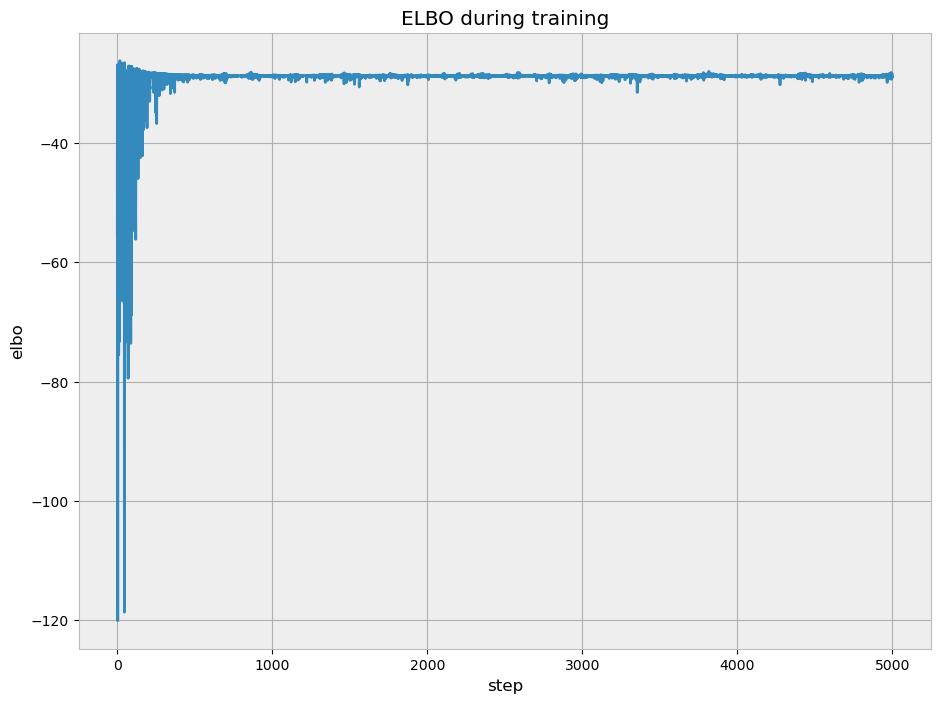

In [4]:
# The fit group holds the ELBO history
idata["fit"].dataset["elbo"].plot()
plt.title("ELBO during training")
plt.show()

In [5]:
# Posterior vs. analytic answer
post_var = 1 / (1 / 25 + obs.size)  # prior precision 1/25 + n data points
post_mean = post_var * obs.sum()

theta_draws = idata["posterior"].dataset["theta"].values.ravel()
print(f"Analytic posterior:  N({post_mean:.3f}, {np.sqrt(post_var):.3f})")
print(f"ADVI posterior:      N({theta_draws.mean():.3f}, {theta_draws.std():.3f})")

Analytic posterior:  N(1.464, 0.223)
ADVI posterior:      N(1.525, 0.222)


## 2.  The `Trainer` object

When you need more control — custom guides, explicit optimizers, resuming
training, or streaming data — use `Trainer` directly.  It separates
construction from execution: configure everything up front, then call
`fit()` and `sample_posterior()`.

Output()

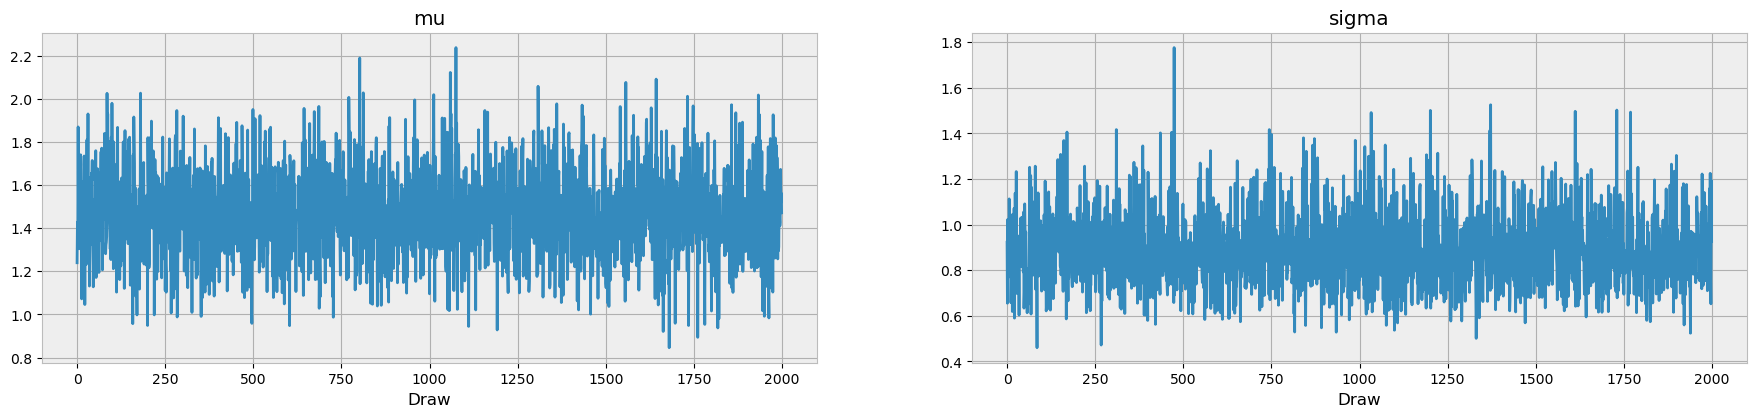

In [6]:
with pm.Model() as model:
    mu = pm.Normal("mu", 0, 10)
    sigma = pm.HalfNormal("sigma", 2)
    pm.Normal("y", mu, sigma, observed=obs)

trainer = Trainer(
    random_seed=42,
)

with model:
    state = trainer.fit(10_000, random_seed=1)
    idata = trainer.sample_posterior(2_000, random_seed=2)

az.plot_trace(idata)
plt.show()

## 3.  Streaming minibatches with an iterator

The real power of the iterator API is training on datasets too large to fit in
memory.  Pass an iterable of `dict` to `fit()` and the trainer streams one
batch per step through `pm.Data` containers.

We'll simulate a linear regression with 100,000 observations and train in
batches of 200.

In [7]:
# Generate a large synthetic dataset
rng = np.random.default_rng(0)
N = 100_000
true_alpha, true_beta, true_sigma = 2.0, np.array([1.5, -0.8, 0.3]), 0.5

X_full = rng.normal(0, 1, size=(N, 3))
y_full = true_alpha + X_full @ true_beta + rng.normal(0, true_sigma, size=N)

print(f"Dataset: {N} rows, {X_full.nbytes / 1e6:.1f} MB for X, {y_full.nbytes / 1e6:.1f} MB for y")

Dataset: 100000 rows, 2.4 MB for X, 0.8 MB for y


In [8]:
batch_size = 200


def batch_iterator(rng, X, y, batch_size):
    """An infinite iterator that yields random minibatches."""
    n = len(y)
    while True:
        idx = rng.integers(n, size=batch_size)
        yield {"X": X[idx], "y": y[idx]}


batches = batch_iterator(rng, X_full, y_full, batch_size)

In [9]:
# Build the model with pm.Data placeholders for the streaming variables
with pm.Model() as regression_model:
    alpha = pm.Normal("alpha", 0, 5)
    beta = pm.Normal("beta", 0, 2, size=3)
    sigma = pm.HalfNormal("sigma", 1)

    X = pm.Data("X", X_full[:batch_size])  # initialised with a dummy batch
    y = pm.Data("y", y_full[:batch_size])

    mu = alpha + X @ beta
    pm.Normal("y_obs", mu, sigma, observed=y)

trainer = Trainer(random_seed=42)
with regression_model:
    state = trainer.fit(5_000, batches, random_seed=1)
    idata = trainer.sample_posterior(2_000, random_seed=2)

Output()

In [10]:
# Check recovery of the true parameters
for var, true_val in [("alpha", true_alpha), ("beta", true_beta), ("sigma", true_sigma)]:
    draws = idata["posterior"].dataset[var].values.squeeze()
    if draws.ndim <= 1:
        print(f"{var}: true={true_val}, ADVI mean={draws.mean():.3f}, ADVI std={draws.std():.3f}")
    else:
        for j in range(draws.shape[-1]):
            col = draws[..., j]
            print(
                f"{var}[{j}]: true={true_val[j]:.3f}, ADVI mean={col.mean():.3f}, ADVI std={col.std():.3f}"
            )

alpha: true=2.0, ADVI mean=1.971, ADVI std=0.035
beta[0]: true=1.500, ADVI mean=1.530, ADVI std=0.038
beta[1]: true=-0.800, ADVI mean=-0.817, ADVI std=0.047
beta[2]: true=0.300, ADVI mean=0.273, ADVI std=0.037
sigma: true=0.5, ADVI mean=0.507, ADVI std=0.027


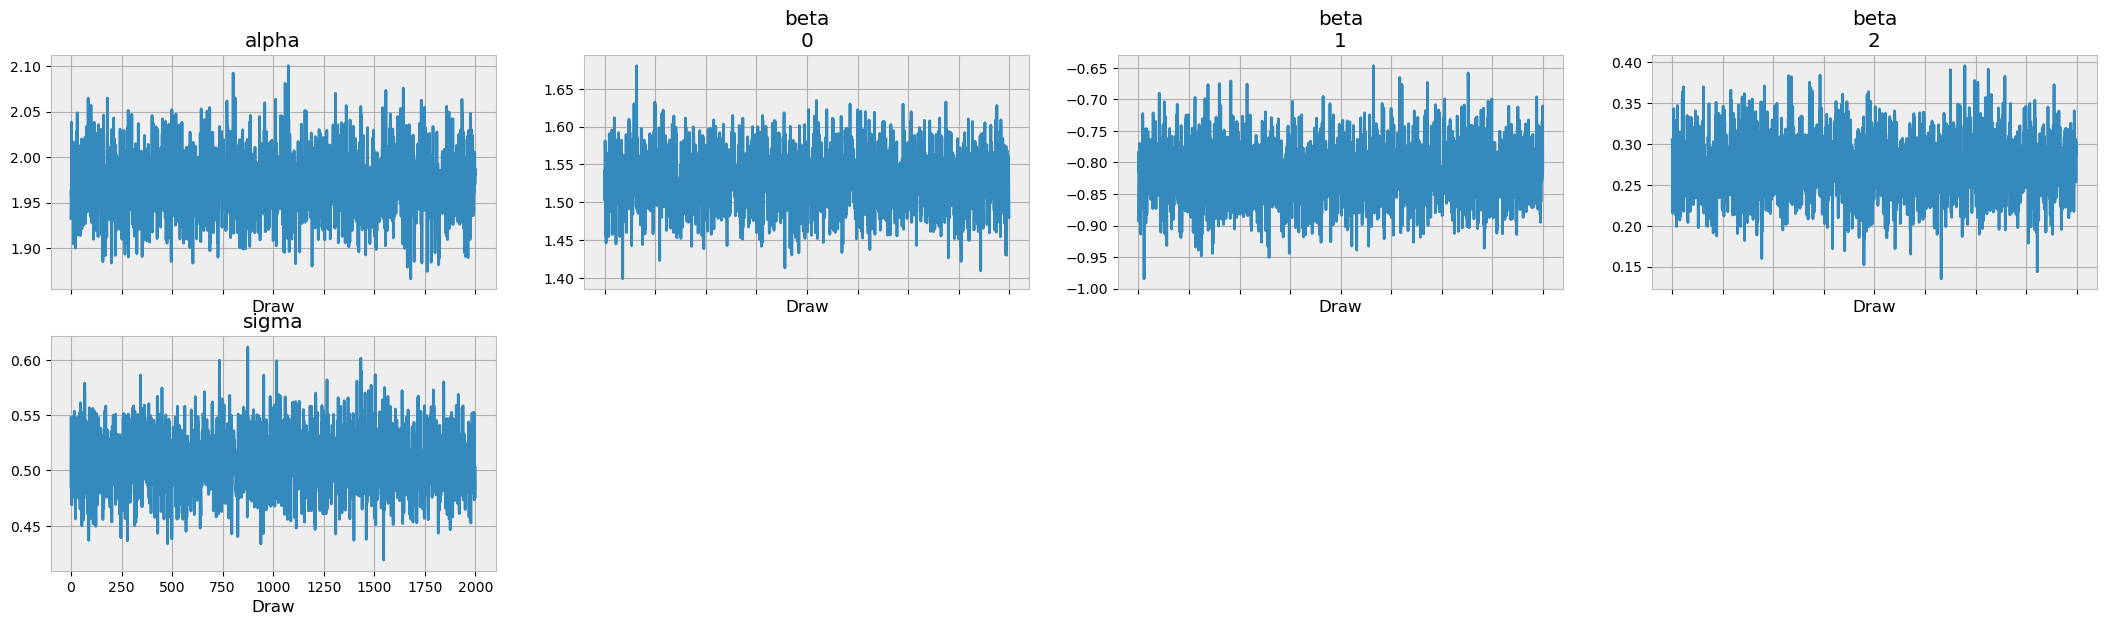

In [11]:
az.plot_trace(idata, var_names=["alpha", "beta", "sigma"])
plt.show()

### 3.1  Likelihood rescaling with `len(iterator)`

When the iterator has a `__len__` that reports the total dataset size `N`,
the trainer automatically rescales each observed variable's log-likelihood by
`N / batch_rows`.  This makes the minibatch ELBO an unbiased estimate of
the full-data ELBO, so the posterior uncertainty is correct.

For `pm.Data` containers the rescaling is automatic; for free RVs streamed
via `observeds` it is automatic too.  Without rescaling, the model sees only
`batch_size` observations and the posterior will be too wide.

In [12]:
class DataLoader:
    """A torch-style dataloader: __len__ is the dataset size, __iter__ yields minibatches."""

    def __init__(self, X, y, batch_size, rng):
        self.X = X
        self.y = y
        self.batch_size = batch_size
        self.rng = rng

    def __len__(self):
        return len(self.y)

    def __iter__(self):
        while True:
            idx = self.rng.integers(len(self.y), size=self.batch_size)
            yield {"X": self.X[idx], "y": self.y[idx]}


loader = DataLoader(X_full, y_full, batch_size, rng)
print(
    f"len(loader) = {len(loader)}  →  rescaling factor = {len(loader)} / {batch_size} = {len(loader) / batch_size:.0f}"
)

len(loader) = 100000  →  rescaling factor = 100000 / 200 = 500


In [13]:
# Fit with rescaling (using the DataLoader which has __len__)
with pm.Model() as model_rescaled:
    alpha = pm.Normal("alpha", 0, 5)
    beta = pm.Normal("beta", 0, 2, size=3)
    sigma = pm.HalfNormal("sigma", 1)

    X = pm.Data("X", X_full[:batch_size])
    y = pm.Data("y", y_full[:batch_size])

    mu = alpha + X @ beta
    pm.Normal("y_obs", mu, sigma, observed=y)

trainer_rescaled = Trainer(random_seed=42)
with model_rescaled:
    state_rescaled = trainer_rescaled.fit(5_000, loader, random_seed=1)
    idata_rescaled = trainer_rescaled.sample_posterior(2_000, random_seed=2)

Output()

In [14]:
# Compare: with vs. without rescaling
# (compute std over draws for each element, then average)
for var in ["alpha", "beta", "sigma"]:
    draws_no = idata["posterior"].dataset[var].values.squeeze()
    draws_scaled = idata_rescaled["posterior"].dataset[var].values.squeeze()
    # Average over parameter dimensions if any, then std over draws
    std_no = draws_no.std(axis=0).mean() if draws_no.ndim > 1 else draws_no.std()
    std_scaled = draws_scaled.std(axis=0).mean() if draws_scaled.ndim > 1 else draws_scaled.std()
    ratio = std_no / std_scaled
    print(
        f"{var}: std without rescaling = {std_no:.4f}, with rescaling = {std_scaled:.4f}, ratio = {ratio:.2f}"
    )

print(f"\nThe rescaling factor is N / batch_size = {N} / {batch_size} = {N / batch_size:.0f}.")
print(
    "The posterior std ratio approaches sqrt(N / batch_size) ="
    f" {np.sqrt(N / batch_size):.1f} as the likelihood dominates the prior."
)
print("(With more steps or a smaller prior the ratio would be closer to this limit.)")

alpha: std without rescaling = 0.0352, with rescaling = 0.0053, ratio = 6.65
beta: std without rescaling = 0.0405, with rescaling = 0.0045, ratio = 9.10
sigma: std without rescaling = 0.0269, with rescaling = 0.0041, ratio = 6.50

The rescaling factor is N / batch_size = 100000 / 200 = 500.
The posterior std ratio approaches sqrt(N / batch_size) = 22.4 as the likelihood dominates the prior.
(With more steps or a smaller prior the ratio would be closer to this limit.)


## 4.  Streaming observations into free random variables

Sometimes you don't want to pre-declare `pm.Data` containers.  The `observeds`
parameter lets you stream data directly into free RVs: the trainer calls
`pm.observe` once (before compilation) and then streams each batch through a
shared variable.  The user's original model is left untouched.

In [15]:
rng = np.random.default_rng(0)


def observation_batches():
    while True:
        yield {"y": rng.normal(3.0, 0.5, size=100)}


with pm.Model() as free_rv_model:
    theta = pm.Normal("theta", 0, 10)
    pm.Normal("y", theta, 1, shape=(100,))  # free RV, not yet observed

trainer = Trainer()
state = trainer.fit(
    2_000, observation_batches(), observeds=["y"], random_seed=1, model=free_rv_model
)
idata = trainer.sample_posterior(1_000, random_seed=2, model=free_rv_model)

Output()

In [16]:
# Only theta appears in the posterior — y was observed
print("Posterior variables:", list(idata["posterior"].dataset.data_vars))

theta_draws = idata["posterior"].dataset["theta"].values.ravel()
print(f"theta: mean = {theta_draws.mean():.3f}, std = {theta_draws.std():.3f}")
print("True mean = 3.0")

# The user's model is unchanged
print(f"\nOriginal model observed_RVs: {[rv.name for rv in free_rv_model.observed_RVs]}")

Posterior variables: ['theta']
theta: mean = 2.945, std = 0.122
True mean = 3.0

Original model observed_RVs: []


## 5.  Finite iterators: training stops when the stream runs out

If the iterator is finite (a generator that eventually raises `StopIteration`),
training stops when the stream is exhausted, even if `n` steps haven't been
reached.  This is useful for one-pass / single-epoch training.

In [17]:
with pm.Model() as model:
    theta = pm.Normal("theta", 0, 10)
    pm.Normal("y", theta, 1, shape=(4,))

# A finite generator: exactly 5 batches
finite_data = ({"y": np.ones(4)} for _ in range(5))

trainer = Trainer()
state = trainer.fit(1_000, finite_data, observeds=["y"], random_seed=1, model=model)

print(f"Requested 1_000 steps, stopped after {state.step} (stream exhausted)")

Output()

Requested 1_000 steps, stopped after 5 (stream exhausted)


## 6.  Resuming training

`fit()` returns an `SVIState` that can be passed back to continue training.
With the default compiled optimizer only the parameters are restored (Adam
moments start fresh); with an explicit optax-like optimizer the full
optimizer state is carried forward.

In [18]:
with pm.Model() as model:
    theta = pm.Normal("theta", 0, 10)
    pm.Normal("y", theta, 1, observed=obs)

trainer = Trainer(random_seed=42)

# First stint
state = trainer.fit(2_000, random_seed=1, model=model)
print(f"After 2k steps: loss = {state.loss_history[-1]:.4f}")

# Resume for another 2k
state = trainer.fit(2_000, state=state, random_seed=2, model=model)
print(f"After 4k steps: loss = {state.loss_history[-1]:.4f}")
print(f"Total steps recorded: {len(state.loss_history)}")

Output()

Output()

After 2k steps: loss = 29.3726


After 4k steps: loss = 29.4054
Total steps recorded: 4000


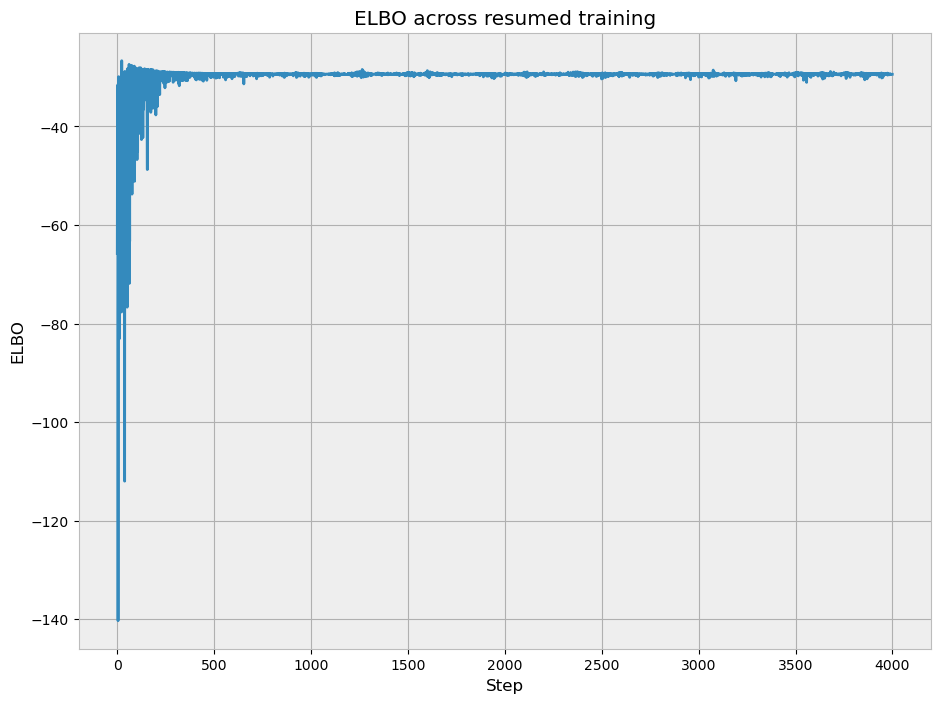

In [19]:
# Loss history across both stints
plt.plot(-np.array(state.loss_history))
plt.xlabel("Step")
plt.ylabel("ELBO")
plt.title("ELBO across resumed training")
plt.show()

## 7.  Custom optimizer

Use the `GradientTransformation` building blocks (`sgd`, `adam`, `clip_by_global_norm`, 
`chain`) to compose an optimizer.  Pass it to `Trainer` via the `optimizer` parameter.


In [20]:
from pymc_extras.inference.advi import sgd

# Build an SGD optimizer from the building blocks.
# GradientTransformation wraps init/update logic; chain composes them.
optimizer = sgd(1e-3)


with pm.Model() as model:
    theta = pm.Normal("theta", 0, 10)
    pm.Normal("y", theta, 1, observed=obs)

trainer = Trainer(optimizer=optimizer)
state = trainer.fit(3_000, random_seed=1, model=model)
idata = trainer.sample_posterior(1_000, random_seed=2, model=model)

theta_draws = idata["posterior"].dataset["theta"].values.ravel()
print(f"theta: mean = {theta_draws.mean():.3f}, std = {theta_draws.std():.3f}")

Output()

theta: mean = 1.494, std = 0.218


## 8.  Putting it all together: minibatch ADVI on a realistic regression

A complete worked example: 50,000-row Poisson regression with 10 features,
trained in minibatches of 128 with likelihood rescaling.

In [21]:
rng = np.random.default_rng(42)

# Synthetic data
N_large = 50_000
D = 10
true_intercept = 0.5
true_coefs = rng.normal(0, 0.5, size=D)

X_large = rng.normal(0, 1, size=(N_large, D))
log_rate = true_intercept + X_large @ true_coefs
y_large = rng.poisson(np.exp(log_rate))

print(f"Dataset: {N_large} rows × {D} features")
print(f"y range: [{y_large.min()}, {y_large.max()}], mean = {y_large.mean():.2f}")

Dataset: 50000 rows × 10 features
y range: [0, 1343], mean = 5.07


In [22]:
batch_size_large = 128


class PoissonDataLoader:
    def __init__(self, X, y, batch_size, rng):
        self.X = X
        self.y = y
        self.batch_size = batch_size
        self.rng = rng

    def __len__(self):
        return len(self.y)

    def __iter__(self):
        while True:
            idx = self.rng.integers(len(self.y), size=self.batch_size)
            yield {"X": self.X[idx], "y": self.y[idx]}


poisson_loader = PoissonDataLoader(X_large, y_large, batch_size_large, rng)

In [23]:
with pm.Model() as poisson_model:
    intercept = pm.Normal("intercept", 0, 2)
    coefs = pm.Normal("coefs", 0, 1, size=D)

    X_data = pm.Data("X", X_large[:batch_size_large])
    y_data = pm.Data("y", y_large[:batch_size_large])

    rate = pm.math.exp(intercept + X_data @ coefs)
    pm.Poisson("y_obs", rate, observed=y_data)

trainer = Trainer(
    random_seed=42,
)
with poisson_model:
    state = trainer.fit(10_000, poisson_loader, random_seed=1)
    idata = trainer.sample_posterior(2_000, random_seed=2)

Output()

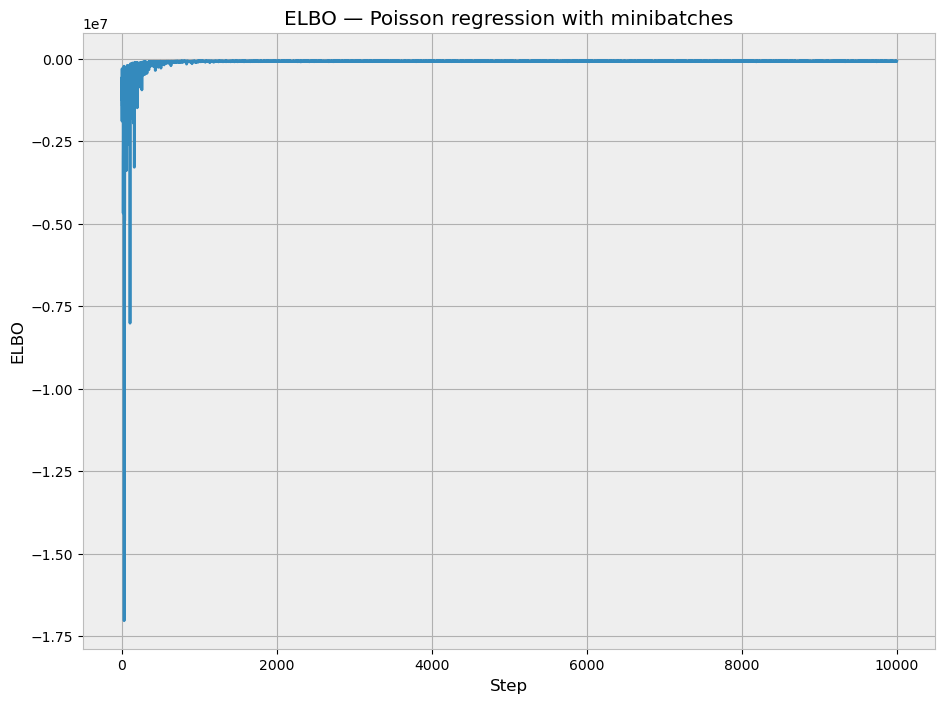

In [24]:
# ELBO history
elbo = -np.array(state.loss_history)
plt.plot(elbo)
plt.xlabel("Step")
plt.ylabel("ELBO")
plt.title("ELBO — Poisson regression with minibatches")
plt.show()

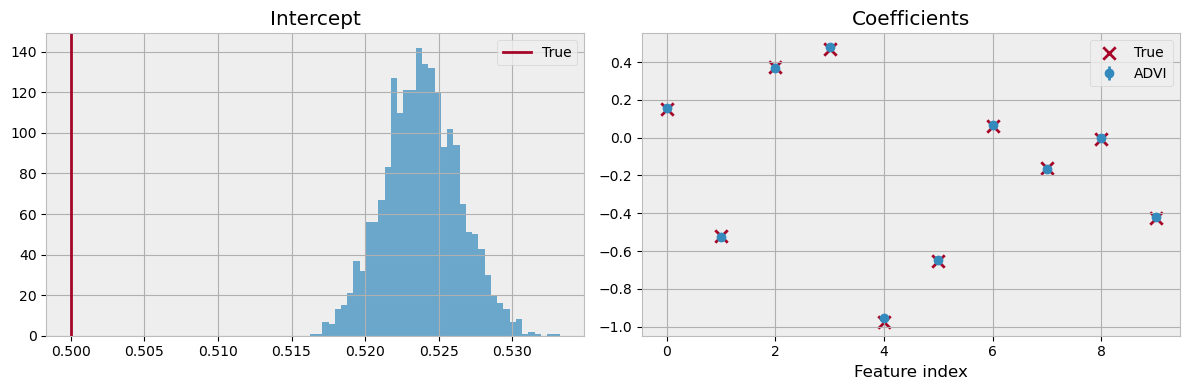

In [25]:
# Compare ADVI estimates to true values
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].axvline(true_intercept, color="C1", linewidth=2, label="True")
axes[0].hist(idata["posterior"].dataset["intercept"].values.ravel(), bins=40, alpha=0.7)
axes[0].set_title("Intercept")
axes[0].legend()

coef_draws = idata["posterior"].dataset["coefs"].values.squeeze()
coef_means = coef_draws.mean(axis=0)
coef_stds = coef_draws.std(axis=0)
idx = np.arange(D)
axes[1].errorbar(idx, coef_means, yerr=coef_stds, fmt="o", label="ADVI")
axes[1].scatter(idx, true_coefs, color="C1", marker="x", s=80, label="True")
axes[1].set_title("Coefficients")
axes[1].legend()
axes[1].set_xlabel("Feature index")

plt.tight_layout()
plt.show()

In [26]:
print("\nParameter recovery:")
print(f"{'Parameter':<12} {'True':>8} {'ADVI mean':>10} {'ADVI std':>10}")
print("-" * 44)
print(
    f"{'intercept':<12} {true_intercept:>8.3f} {coef_draws.mean():>10.3f} {coef_draws.std():>10.3f}"
)
for i in range(D):
    print(
        f"{'coefs[' + str(i) + ']':<12} {true_coefs[i]:>8.3f} {coef_means[i]:>10.3f} {coef_stds[i]:>10.3f}"
    )


Parameter recovery:
Parameter        True  ADVI mean   ADVI std
--------------------------------------------
intercept       0.500     -0.164      0.441
coefs[0]        0.152      0.159      0.002
coefs[1]       -0.520     -0.527      0.002
coefs[2]        0.375      0.371      0.002
coefs[3]        0.470      0.478      0.002
coefs[4]       -0.976     -0.956      0.002
coefs[5]       -0.651     -0.648      0.002
coefs[6]        0.064      0.068      0.003
coefs[7]       -0.158     -0.164      0.003
coefs[8]       -0.008     -0.002      0.002
coefs[9]       -0.427     -0.418      0.003
